# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [6]:
# Import the library
from PIL import Image
import numpy as np
 

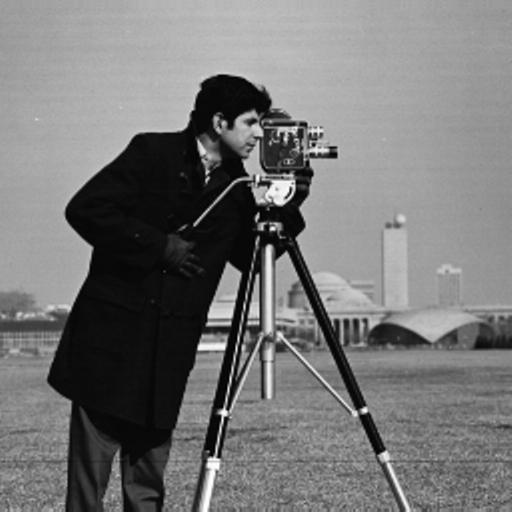

In [7]:
# ── Load image ────────────────────────────────────
img = Image.open('cameraman.jpg')
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [9]:
# Get the size of the image
w , h =img.size
# scaling factors
cx , cy = 2 , 2



In [10]:
# ── 1. Increase size (scale ×2) ────────────────────
new_w = int(w * cx)
new_h = int(h * cy)

# Resize the image using PIL's built-in method
img_scaled= img.resize((new_w, new_h), Image.Resampling.LANCZOS)


In [11]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
img_scaled.save('task1_1_scaled.jpg')

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [14]:
f = img.transform(
    (w,h),
    Image.AFFINE,
    (-1,0,w,
     0,1,0)
    
)

In [15]:
f.save('task1_2_flipped.jpg')

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [31]:
# ── 2. Rotate 120 degrees ──────────────────────────
img_rotated = img.rotate(120, resample=Image.Resampling.BICUBIC, expand=True)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
img_rotated.save('task1_2_rotated.jpg')

### 3. Shear

In [ ]:
# -- c. Get the image dimensions ────────────────────
w, h = img.size


In [32]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5  # Shear factor for X-axis
shy = 0.0  # Shear factor for Y-axis


In [34]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
shearesd = img.transform(
    (w, h),
    Image.AFFINE,
    (1, shx, 0,
     shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)


In [35]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
shearesd.save('task1_3_sheared.jpg')

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results




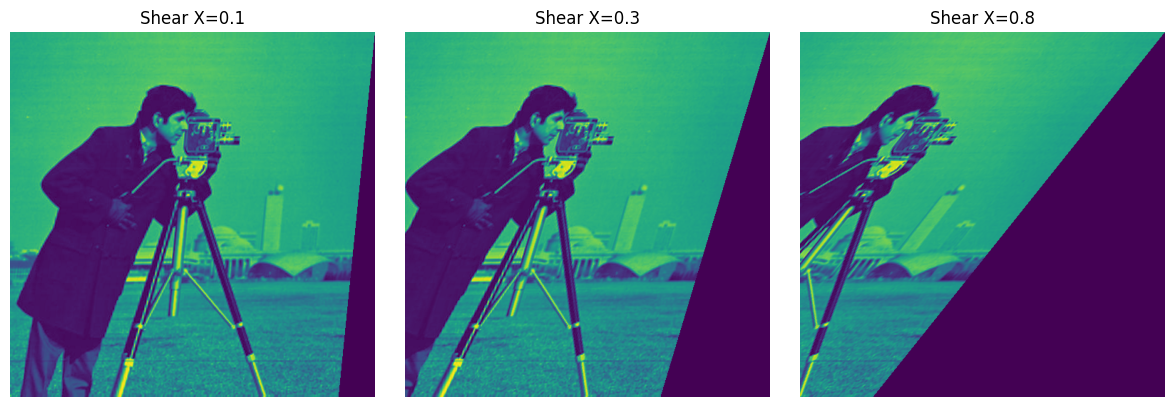

In [43]:
shear_values = [0.1, 0.3, 0.8]

plt.figure(figsize=(12, 4))
for i, shx in enumerate(shear_values):
    sheared_img = img.transform(
        (w, h),
        Image.AFFINE,
        (1, shx, 0,
         0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )
    plt.subplot(1, len(shear_values), i + 1)
    plt.imshow(sheared_img)
    plt.title(f'Shear X={shx}')
    plt.axis('off')
plt.tight_layout()
plt.show()



— Switch from X-axis to Y-axis shear matrix



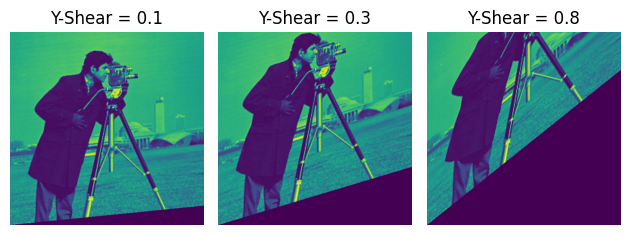

In [ ]:


for i, shy in enumerate(shear_values):
    shx = 0.0   
    
    sheared = img.transform(
        (w, h),
        Image.AFFINE,
        (1, shx, 0,
         shy, 1, 0),
        resample=Image.Resampling.BICUBIC
    )
    
    plt.subplot(1, 3, i + 1)
    plt.imshow(sheared)
    plt.title(f"Y-Shear = {shy}")
    plt.axis("off")

plt.tight_layout()
plt.show()



— Update the canvas multiplier to match your new factor


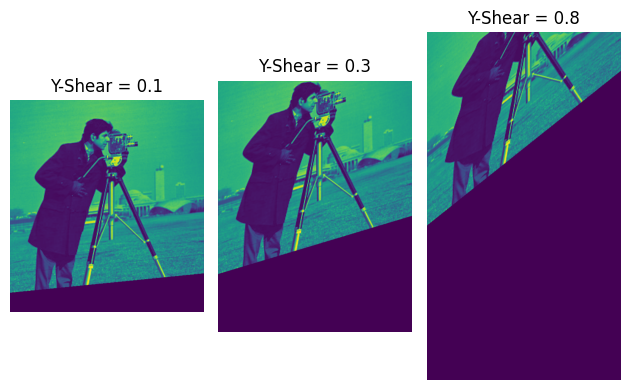

In [ ]:
for i, shy in enumerate(shear_values):
    shx = 0.0
    
    #  Update canvas size
    new_w = w
    new_h = int(h + abs(shy) * w)

    sheared = img.transform(
        (new_w, new_h),
        Image.AFFINE,
        (1, shx, 0,
         shy, 1, 0),
        resample=Image.Resampling.BICUBIC
    )
    
    plt.subplot(1, 3, i + 1)
    plt.imshow(sheared)
    plt.title(f"Y-Shear = {shy}")
    plt.axis("off")

plt.tight_layout()
plt.show()


— Try combining X and Y shear in one matrix

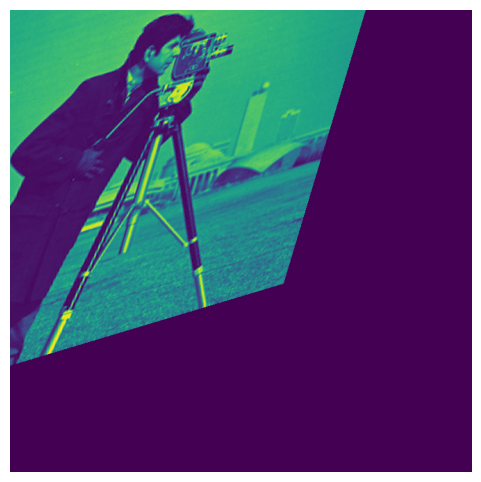

In [49]:
shx = 0.3   # X shear factor
shy = 0.3   # Y shear factor

# Update canvas for both directions
new_w = int(w + abs(shx) * h)
new_h = int(h + abs(shy) * w)

combined_shear = img.transform(
    (new_w, new_h),
    Image.AFFINE,
    (1, shx, 0,
     shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

plt.figure(figsize=(6, 6))
plt.imshow(combined_shear)
plt.axis("off")
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [ ]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr =np.array(img)
negative_arr = 255 - arr
negative_img = Image.fromarray(negative_arr)
negative_img.save('task2_1_negative.jpg')



In [39]:
# Method 2: PIL's ImageOps
from PIL import ImageOps        
negative_img2 = ImageOps.invert(img)
negative_img2.save('task2_1_negative2.jpg') 


In [40]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c= 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)
log_transformed_arr = Image.fromarray(np.uint8(log_transformed_arr))
log_transformed_arr.save('task2_2_log_transformed.jpg')


/tmp/ipykernel_45531/534853732.py:11: RuntimeWarning: divide by zero encountered in log
  log_transformed_arr = c * np.log(1 + arr)
/tmp/ipykernel_45531/534853732.py:12: RuntimeWarning: invalid value encountered in cast
  log_transformed_arr = Image.fromarray(np.uint8(log_transformed_arr))


In [ ]:


# ── 3. Power-law / Gamma correction ───────────────

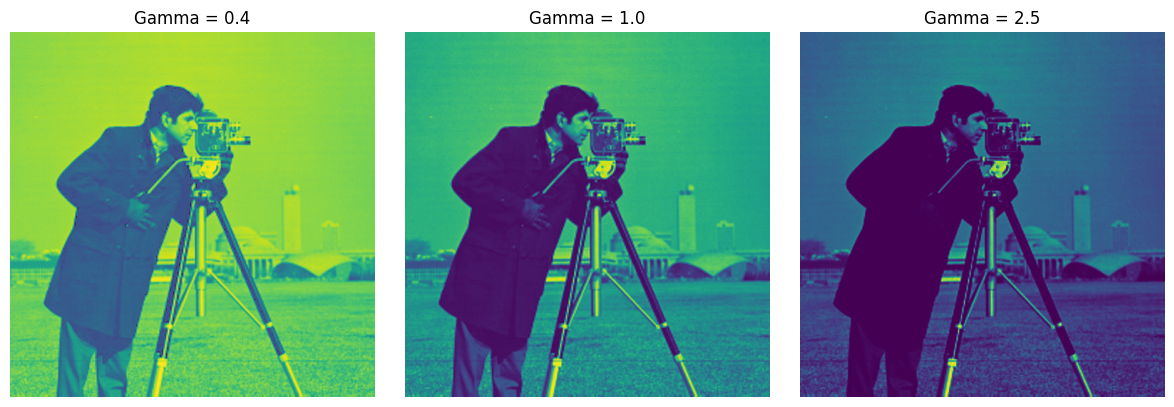

In [41]:
import matplotlib.pyplot as plt
# Define gamma values to test
gamma_values = [0.4, 1.0, 2.5]
plt.figure(figsize=(12, 4))

img_array = np.array(img) / 255.0  # move outside loop

for i, gamma in enumerate(gamma_values):
    gamma_img = np.power(img_array, gamma)

    plt.subplot(1, 3, i + 1)
    plt.imshow(gamma_img)   # no cmap unless grayscale
    plt.title(f'Gamma = {gamma}')
    plt.axis('off')

plt.tight_layout()
plt.show()